# Fourth Trial Set: Z-Score Cluster Scoring

Z-Score scoring applied to the full Fourth Trial Set (`Fourth_Trial_Set_PDM_Rezepturen_Gesamt_28-07-2026.xlsx`).

Pipeline:
1. Load recipes from "Rezepte Gesamt AJ" sheet; resolve CAS numbers via "CAS Nr." lookup
2. Zero out carrier/solvent substances listed in "Normalisierung" sheet (167 substances)
3. Normalize ingredient amounts per recipe (sum to 1)
4. Apply Z-Score: replace normalized amount with amount / AvgMeli per CAS (Melanie reference)
5. Score each recipe against 7 clusters using the updated Scoring Index weight matrix
6. Assign each recipe to the argmax cluster


In [1]:
import sys
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from pathlib import Path
from ms_scoring import (
    load_fourth_trial_recipes,
    load_fourth_trial_weight_matrix,
    load_avg_meli,
    apply_zscore_quantities,
    compute_scores,
    normalize_scores,
    assign_clusters,
    CLUSTER_COLS,
)

FOURTH_TRIAL = Path("../data/gold/Fourth_Trial_Set_PDM_Rezepturen_Gesamt_28-07-2026.xlsx")
OLD_SCORING  = Path("../data/gold/Scoring Index_Beispielrechung.xlsx")
OUT_XLSX     = Path("../outputs/scoring_fourth_trial.xlsx")
OUT_PLOT     = Path("../outputs/fourth_trial_score_profiles.png")

MS_TO_PANEL = {
    "warm":       "warm",
    "Unpleasant": "unpleasant",
    "green":      "green",
    "floral":     "floral",
    "citrus":     "fruity",
}


## 1. Load Recipes

In [2]:
recipes = load_fourth_trial_recipes(FOURTH_TRIAL)

n_recipes = recipes["Rez.-Nr."].nunique()
n_rows    = len(recipes)
n_cas     = recipes["CAS-Nr."].nunique()

print(f"Recipes loaded: {n_recipes}")
print(f"Ingredient rows: {n_rows:,}")
print(f"Unique CAS numbers: {n_cas}")
print()
print("Sample rows:")
print(recipes.head(5).to_string(index=False))


INFO: 4684 ingredient rows have no CAS-Nr. match and are dropped
Recipes loaded: 6392
Ingredient rows: 141,033
Unique CAS numbers: 726

Sample rows:
Rez.-Nr.   CAS-Nr.  Totalmenge
 185.046 8022-96-6    0.001965
 185.046  110-43-0    0.019646
 185.046  116-53-0    0.086444
 185.046  109-21-7    0.145383
 185.046  928-96-1    0.440079


## 2. Weight Matrix (Scoring Index)

In [3]:
weights = load_fourth_trial_weight_matrix(FOURTH_TRIAL)

print(f"Weight matrix: {weights.shape[0]} CAS x {weights.shape[1]} clusters")
print()
print("Column sums (total weight capacity per cluster):")
print(weights.sum().to_string())
print()
print("Top 5 rows:")
print(weights[weights.sum(axis=1) > 0].head(5).to_string())


Weight matrix: 224 CAS x 7 clusters

Column sums (total weight capacity per cluster):
Unpleasant    114
warm          256
green          72
floral        225
citrus         78
exotic         39
Outlayer       66

Top 5 rows:
            Unpleasant  warm  green  floral  citrus  exotic  Outlayer
CAS                                                                  
14667-55-1           3     3      0       0       0       0         3
116-53-0             2     2      0       0       2       2         0
7786-61-0            3     0      0       0       0       0         0
75-07-0              3     0      0       0       0       0         0
3390-12-3            3     0      0       0       0       0         0


## 3. AvgMeli Reference (Melanie's Calibration)

In [4]:
avg_meli = load_avg_meli(OLD_SCORING, csv_path=None)

print(f"AvgMeli entries: {len(avg_meli)}")
print()

# Coverage: how many recipe CAS have a valid AvgMeli?
recipe_cas = set(recipes["CAS-Nr."].unique())
covered = recipe_cas & set(avg_meli[avg_meli > 0].index)
print(f"Recipe CAS with valid AvgMeli: {len(covered)} / {len(recipe_cas)} "
      f"({100 * len(covered) / len(recipe_cas):.1f}%)")
print()
print("Note: CAS without AvgMeli contribute 0 to the Z-Score (zeroed out by apply_zscore_quantities).")


AvgMeli entries: 224

Recipe CAS with valid AvgMeli: 216 / 726 (29.8%)

Note: CAS without AvgMeli contribute 0 to the Z-Score (zeroed out by apply_zscore_quantities).


**Coverage note:** Only ~30% of the CAS numbers in the Fourth Trial Set have a valid AvgMeli entry from Melanie's reference file. The remaining CAS are zeroed out by the Z-Score transform and contribute nothing to the scores.

This is expected: Melanie's AvgMeli was calibrated on strawberry reference recipes, while the Fourth Trial Set covers all aroma types. Cluster assignments for non-strawberry recipes therefore rely primarily on the weight matrix rather than the Z-Score calibration. Results should be treated as indicative and validated against panel tastings where possible.

## 4. Z-Score Scoring

In [5]:
recipes_z = apply_zscore_quantities(recipes, avg_meli)
scores_z  = compute_scores(recipes_z, weights)
ms_z      = assign_clusters(scores_z)

print("Cluster distribution (Z-Score):")
dist = ms_z.value_counts().rename("count")
dist["total"] = dist.sum()
print(dist.to_string())
print()
print(f"Recipes with a valid Z-Score assignment: {ms_z.notna().sum()}")


Cluster distribution (Z-Score):
MS_cluster
floral        2258
warm          1563
green          863
Unpleasant     688
citrus         608
exotic         235
Outlayer       177
total         6392

Recipes with a valid Z-Score assignment: 6392


## 5. Score Profiles per Cluster

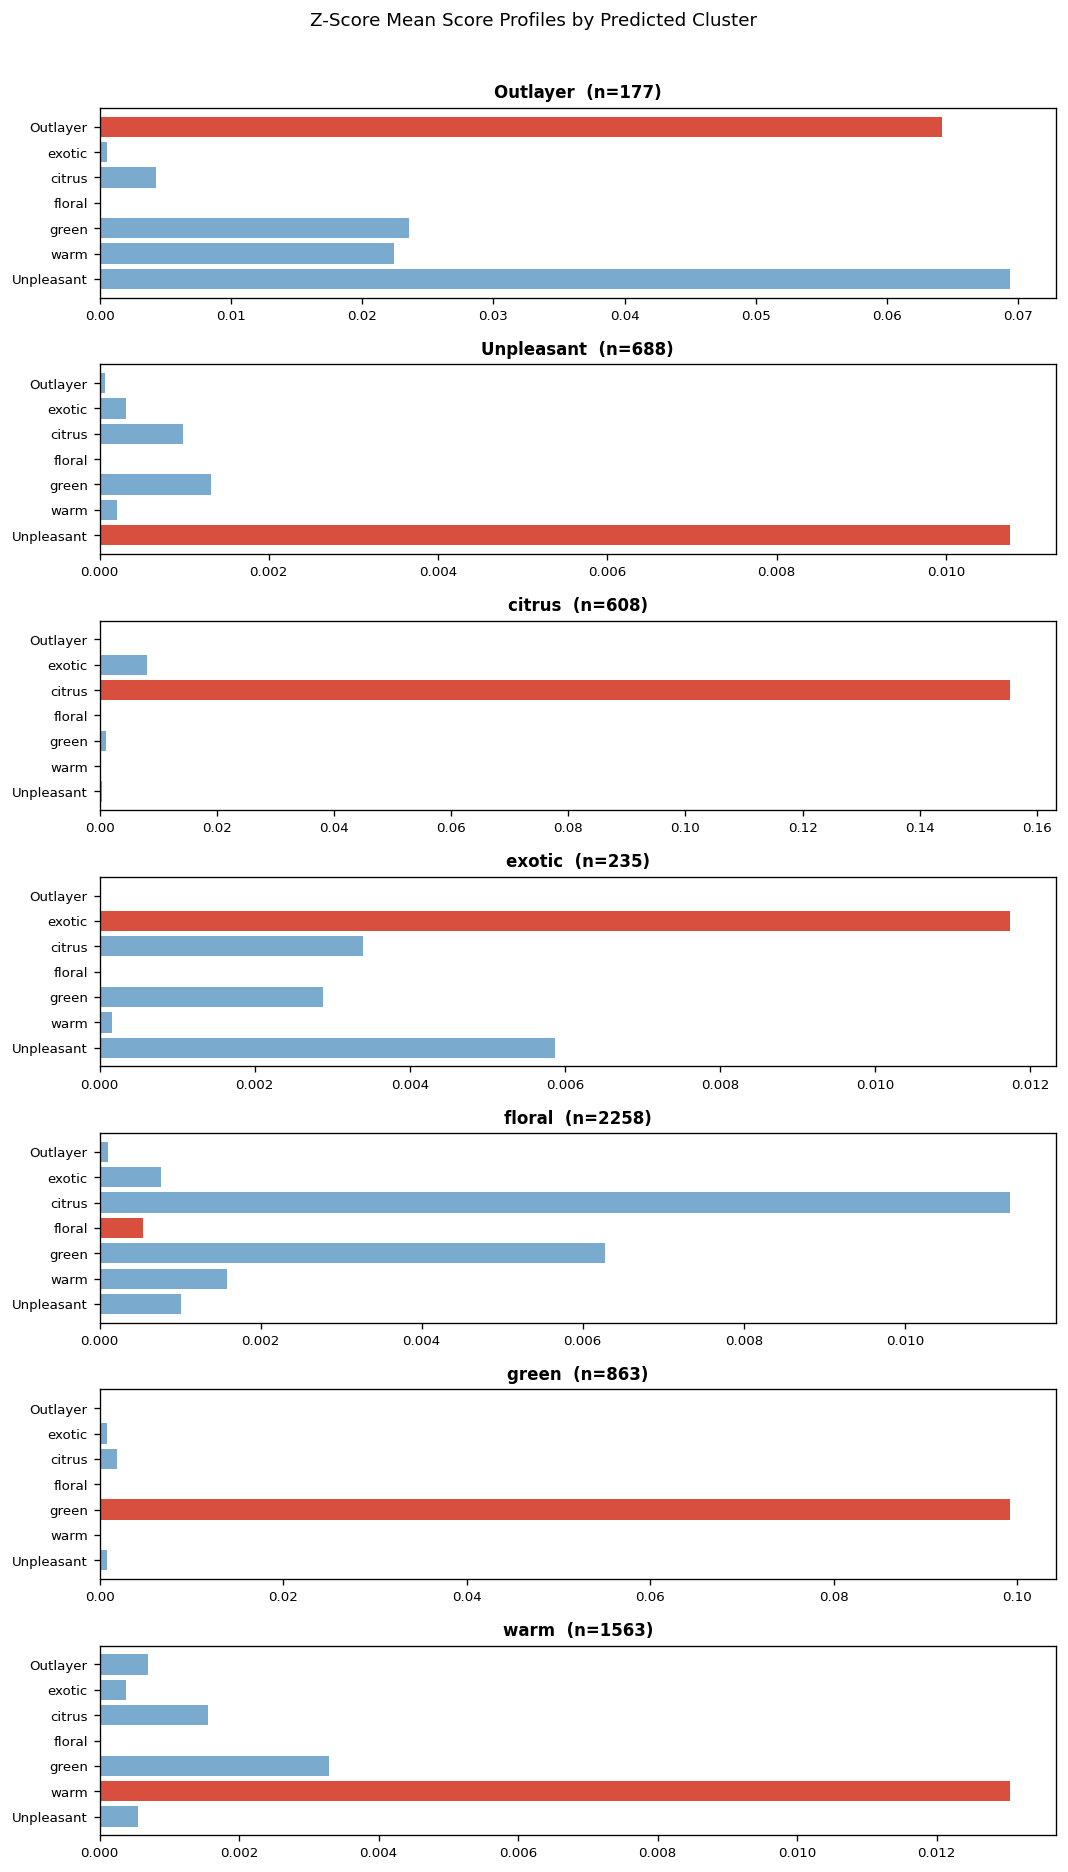

Saved: ../outputs/fourth_trial_score_profiles.png


In [6]:
scores_z_norm = normalize_scores(scores_z)

# Compute mean normalized profile per predicted cluster
profile = scores_z_norm.copy()
profile["cluster"] = ms_z
mean_profile = profile.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile), 1, figsize=(9, 2.2 * len(mean_profile)), sharey=False)
if len(mean_profile) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile.iterrows()):
    n = (ms_z == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Z-Score Mean Score Profiles by Predicted Cluster", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_PLOT, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PLOT}")


## 6. Export Predictions

In [7]:
ms_z_panel = ms_z.map(MS_TO_PANEL)

pred_all = pd.DataFrame({
    "ZScore_cluster":    ms_z,
    "ZScore_panel_name": ms_z_panel,
}).join(scores_z.round(4).add_prefix("Score_"))
pred_all = pred_all.sort_values("ZScore_cluster")

print(f"Total recipes exported: {len(pred_all)}")
print()
print("Cluster distribution:")
print(pred_all["ZScore_cluster"].value_counts().to_string())
print()
print("Panel-equivalent distribution (where mapped):")
print(pred_all["ZScore_panel_name"].value_counts().to_string())

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    pred_all.to_excel(writer, sheet_name="ZScore_All_Predictions")
    slim = pred_all[["ZScore_cluster", "ZScore_panel_name"]].copy()
    slim.index.name = "Recipe"
    slim.to_excel(writer, sheet_name="ZScore_Predictions_Slim")

print()
print(f"Saved: {OUT_XLSX}")
print("Sheets: ZScore_All_Predictions, ZScore_Predictions_Slim")
print("Note: ZScore_panel_name is the model prediction in panel vocabulary, not a panel assessment.")


Total recipes exported: 6392

Cluster distribution:
ZScore_cluster
floral        2258
warm          1563
green          863
Unpleasant     688
citrus         608
exotic         235
Outlayer       177

Panel-equivalent distribution (where mapped):
ZScore_panel_name
floral        2258
warm          1563
green          863
unpleasant     688
fruity         608



Saved: ../outputs/scoring_fourth_trial.xlsx
Sheets: ZScore_All_Predictions, ZScore_Predictions_Slim
Note: ZScore_panel_name is the model prediction in panel vocabulary, not a panel assessment.


## 7. Raw MS Scoring (Weight Matrix Only)

Instead of dividing by AvgMeli, use the normalized ingredient amounts directly.
Every recipe and every CAS is treated equally: no calibration against reference recipes.
This gives consistent coverage across all 6,392 recipes regardless of aroma type.

In [8]:
scores_ms  = compute_scores(recipes, weights)
ms_raw     = assign_clusters(scores_ms)
ms_raw_panel = ms_raw.map(MS_TO_PANEL)

print("Cluster distribution (raw MS, weight matrix only):")
dist_ms = ms_raw.value_counts().rename("count")
print(dist_ms.to_string())
print()

# Side-by-side comparison
comp = pd.DataFrame({
    "MS_raw": ms_raw.value_counts(),
    "Z-Score": ms_z.value_counts(),
}).fillna(0).astype(int).sort_index()
comp["diff"] = comp["MS_raw"] - comp["Z-Score"]
print("Comparison vs Z-Score:")
print(comp.to_string())


Cluster distribution (raw MS, weight matrix only):
MS_cluster
warm          2396
green         1034
floral         896
Unpleasant     765
citrus         756
exotic         460
Outlayer        85

Comparison vs Z-Score:
            MS_raw  Z-Score  diff
MS_cluster                       
Outlayer        85      177   -92
Unpleasant     765      688    77
citrus         756      608   148
exotic         460      235   225
floral         896     2258 -1362
green         1034      863   171
warm          2396     1563   833


## 8. Score Profiles per Cluster (Raw MS)

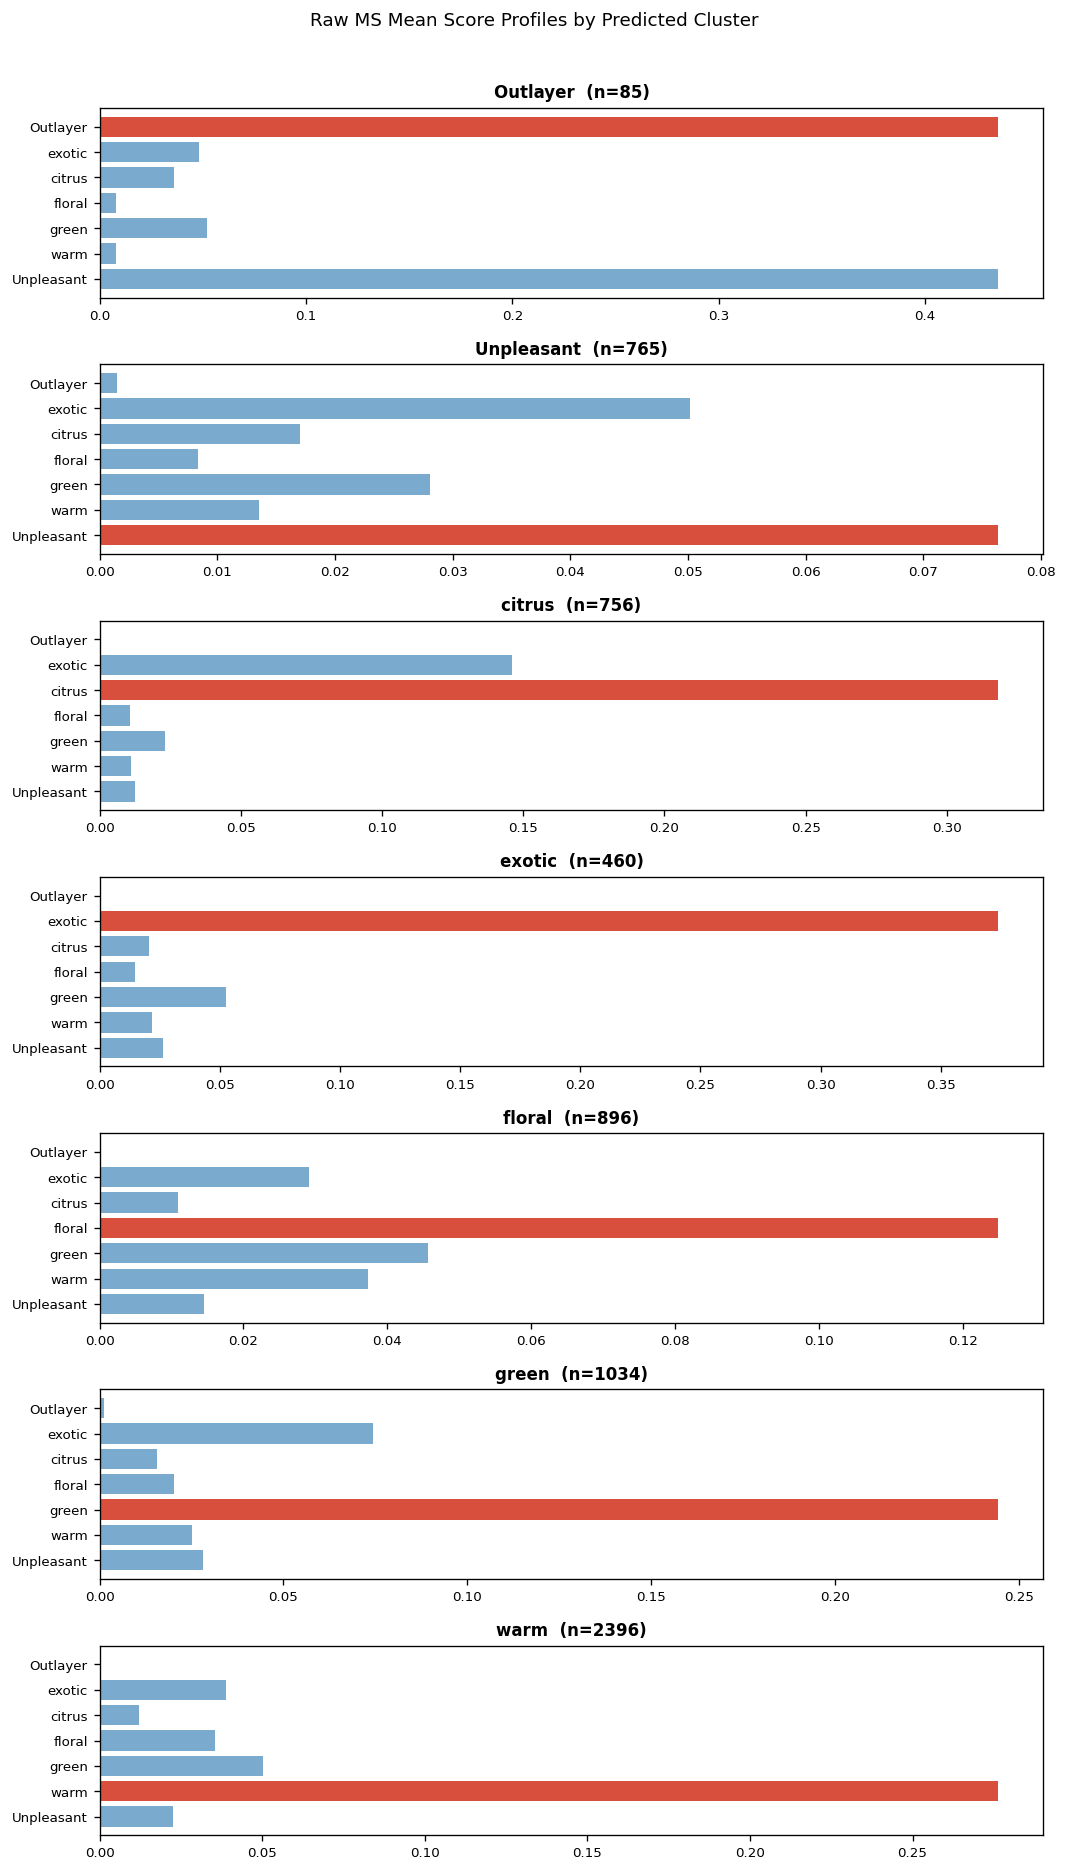

Saved: ../outputs/fourth_trial_score_profiles_ms.png


In [9]:
scores_ms_norm = normalize_scores(scores_ms)

profile_ms = scores_ms_norm.copy()
profile_ms["cluster"] = ms_raw
mean_profile_ms = profile_ms.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile_ms), 1,
                         figsize=(9, 2.2 * len(mean_profile_ms)), sharey=False)
if len(mean_profile_ms) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile_ms.iterrows()):
    n = (ms_raw == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Raw MS Mean Score Profiles by Predicted Cluster", fontsize=11, y=1.01)
plt.tight_layout()

out_plot_ms = Path("../outputs/fourth_trial_score_profiles_ms.png")
plt.savefig(out_plot_ms, bbox_inches="tight")
plt.show()
print(f"Saved: {out_plot_ms}")


## 9. Export Raw MS Predictions

In [10]:
pred_ms = pd.DataFrame({
    "MS_cluster":    ms_raw,
    "MS_panel_name": ms_raw_panel,
}).join(scores_ms.round(4).add_prefix("Score_"))
pred_ms = pred_ms.sort_values("MS_cluster")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    pred_ms.to_excel(writer, sheet_name="MS_All_Predictions")
    slim_ms = pred_ms[["MS_cluster", "MS_panel_name"]].copy()
    slim_ms.index.name = "Recipe"
    slim_ms.to_excel(writer, sheet_name="MS_Predictions_Slim")

print(f"Added to {OUT_XLSX}:")
print("  MS_All_Predictions")
print("  MS_Predictions_Slim")
print()
print("Note: MS_panel_name is the model prediction in panel vocabulary, not a panel assessment.")


Added to ../outputs/scoring_fourth_trial.xlsx:
  MS_All_Predictions
  MS_Predictions_Slim

Note: MS_panel_name is the model prediction in panel vocabulary, not a panel assessment.
